<a href="https://colab.research.google.com/github/satrishabh/ML-DL-GENAI/blob/main/LangChain_Agentic_A4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
!pip install -q langchain langchain-google-genai

In [23]:
import os
import json
from getpass import getpass
from typing import Any
from langchain.tools import tool
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.tools import tool
from langchain.agents import create_agent
from pydantic import BaseModel, Field

In [24]:
# Evry time we don't have to run all and want the key
if "GOOGLE_API_KEY" not in os.environ:
  os.environ["GOOGLE_API_KEY"]=getpass("Enter your Gemini API Key:")

In [25]:
symptom_category_keywords = {
    "respiratory": [
        "cough",
        "breathing difficulty",
        "shortness of breath",
        "chest congestion"
    ],

    "cardiac": [
        "chest pain",
        "palpitations",
        "heart rate",
        "dizziness"
    ],

    "infection": [
        "fever",
        "chills",
        "body ache",
        "fatigue"
    ]
}

In [26]:
severity_weights = {
    "breathing difficulty": 30,
    "chest pain": 35,
    "high fever": 20,
    "dizziness": 15,
    "mild cough": 5
}

In [27]:
#helper functions
def normalize_text(text:str)->str:
  return " ".join(text.lower().strip().split())

In [28]:
def identify_categories(symptom: str)->list[str]:
  text=normalize_text(symptom)
  categories=[]
  for category, keywords in symptom_category_keywords.items():
    for keyword in keywords:
      if keyword in text:
        categories.append(category)
        break
  return categories

In [29]:
class HealthcareAssessmentInput(BaseModel):
    symptom: str = Field(description="Patient symptoms in natural language.")
    age: int | None = Field(default=None, description="Patient age if known.")
    duration: str | None = Field(default=None, description="How long the symptoms have been present, if known.")
    basic_information: str | None = Field(default=None, description="Other relevant patient information.")

In [31]:
@tool(args_schema=HealthcareAssessmentInput)
def healthcare_assessment(
    symptom:str,
    age: int|None=None,
    duration:str|None=None,
    basic_information:str|None=None,
)->dict[str, Any]:
    """
    Perform a synthetic initial healthcare triage assessment.

    Use this tool whenever a user provides patient
    symptoms and asks for an urgency or risk assessment.

    The tool does not diagnose diseases.
    It only calculates a synthetic severity score based on
    predefined educational risk indicators.
    """
    normalized_symptom = normalize_text(symptom)
    categories = identify_categories(normalized_symptom)

    severity_score = 0
    for keyword, weight in severity_weights.items():
        if keyword in normalized_symptom:
            severity_score += weight

    # Placeholder for more complex logic based on age, duration, basic_information
    # For this example, we'll keep it simple and symptom-based.

    return {
        "symptom_categories": categories,
        "synthetic_severity_score": severity_score,
        "assessment_message": f"Based on the symptoms, the synthetic severity score is {severity_score}. This is a preliminary assessment and not a diagnosis."
    }

In [35]:
result=healthcare_assessment.invoke({
    "symptom":"chest pain, breathing difficulty, dizziness",
    "age": 62,
    "duration":"since this morning",
    "basic_information":"I have a heart condition"
})

print(json.dumps(result, indent=2))

{
  "symptom_categories": [
    "respiratory",
    "cardiac"
  ],
  "synthetic_severity_score": 80,
  "assessment_message": "Based on the symptoms, the synthetic severity score is 80. This is a preliminary assessment and not a diagnosis."
}


In [36]:
model=ChatGoogleGenerativeAI(model="gemini-3.5-flash",temperature=0.2)


In [37]:
system_prompt="""
You are a healthcare patient Triage Assistant, your role is to support a initial urgency assement. You are not a doctor and you must never provide a definitive medical diagnosis.

Important rules:

1. when the user provides patient symptoms and asks for an urgency, risk, severity or triage assement, ALWAYS use the healthcare_assessment tool.
2. do not calculate the sevireity score yourself. the python healthcare_assement tool is the source of synthetic severity score.
3. do not invent/ create a new missing patient information from the initial given. expilicity identify if unknown
4. clearly distinguish between:
-symptoms reported by the user
-synthetic risk indicators
-the tool's severity assesment
-the recommendation
5.Never claim that the patient has the disease or medical condition. Always use the healthcare_assessment tool.
6.if the tool indicates that human intervention is required, clearly place that warning first.
7.if symptoms do not match any predefiend category, explain that the synthetic tool cannot meaningfullu classify them and that human assesment may be appropriate.
8.keep response concise and structured
9.Use the follwoing response structure:
-risk level:
-severity level:
-matched indicators:
-recommendation:
-missing information:
-saftey note:
10.This is a scenario not for real time scenario
11.if there are potentially urgent symptoms such as chest pain, severe breathing difficulty, fainting, confusion, or loss of attention rather than reassurance.
12.base your answer only on the information supplied by the user and the tool output

"""


In [41]:
agent=create_agent(
    model=model,
    tools=[healthcare_assessment],
    system_prompt=system_prompt
)

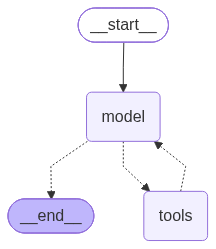

In [42]:
agent

In [43]:
def run_traige(query:str):
  result=agent.invoke({
      "messages":[{
          "role":"user",
          "content":query
      }]
  })
  return result["messages"][-1].content

In [45]:
#test scenrio1

test1="""
Patient is 25 years old and has had a mild cough for two days. There is no breathing difficulty and no chest pain.
"""

result1=run_traige(test1)
print(result1)

[{'type': 'text', 'text': '**Reported Symptoms:**\n* Mild cough (duration: 2 days)\n* No breathing difficulty\n* No chest pain\n\n**Triage Assessment:**\n\n* **risk level:** Low (Synthetic assessment)\n* **severity level:** 5 (Synthetic severity score provided by the tool)\n* **matched indicators:** Respiratory category (mild cough)\n* **recommendation:** Monitor symptoms at home. If the cough worsens, persists for more than a week, or if new symptoms develop, consult a healthcare provider.\n* **missing information:** Temperature (presence of fever), sputum/phlegm characteristics, pre-existing medical conditions (e.g., asthma, allergies), smoking history, and recent exposure to sick individuals are unknown.\n* **saftey note:** This is a synthetic triage simulation and does not constitute a medical diagnosis. If you experience potentially urgent symptoms such as chest pain, severe breathing difficulty, fainting, or confusion, please seek immediate professional medical attention.', 'extr

In [46]:
test2="""
Patient is 48 years old and has fever,fatigue a persistent cough for two days. There is little breathing difficulty and some chest pain.
"""

result2=run_traige(test2)
print(result2)

[{'type': 'text', 'text': "**WARNING: IMMEDIATE HUMAN MEDICAL INTERVENTION IS REQUIRED. The patient is experiencing potentially urgent symptoms (chest pain and breathing difficulty) that require immediate professional medical evaluation.**\n\n**Symptoms Reported by the User:** \nFever, fatigue, persistent cough for two days, mild breathing difficulty, and chest pain in a 48-year-old patient.\n\n- **risk level**: High (due to the presence of potentially urgent cardiac and respiratory symptoms)\n- **severity level**: Synthetic Severity Score: 65 (calculated by the triage tool)\n- **matched indicators**: Respiratory, Cardiac, Infection (synthetic risk indicators identified by the tool)\n- **recommendation**: Seek immediate professional medical assessment or emergency care. Do not delay.\n- **missing information**: \n  - Patient's medical history (unknown)\n  - Specific characteristics of the chest pain (unknown)\n  - Exact temperature of the fever (unknown)\n  - Any other associated sympt